# Bayesian Neural Networks with Bayesian-Torch

This notebook implements Bayesian Neural Networks using **Bayesian-Torch** (Intel Labs), which performs **Stochastic Variational Inference (SVI)** on neural networks. Unlike Laplace approximation (post-hoc), Bayesian-Torch learns the posterior distribution directly during training via ELBO optimization.

## Key Concepts:
- **Reparameterization & Flipout**: Weight sampling with low-variance gradient estimation
- **ELBO Loss**: Likelihood + KL divergence complexity penalty
- **MOPED Initialization**: Initialize from pre-trained MAP model for faster convergence
- **MC Sampling**: Multiple forward passes to estimate epistemic uncertainty

## 1. Import Required Libraries

In [ ]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss

from shared.helper.dataloaders import get_sinusoid_example
from shared.helper.util import plot_regression
from shared import checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything

SEED = 711
seed_everything(SEED)

checkpoint_dir = os.path.join("results", "checkpoints", "bnn_bayesian_torch")
os.makedirs(checkpoint_dir, exist_ok=True)

## 2. Data Setup & Configuration

In [3]:
# Configuration
n_epochs_map = 1000      # MAP training epochs
n_epochs_bnn = 1000      # BNN fine-tuning epochs
num_mc_samples = 100     # MC samples for inference
sigma_noise = 0.3        # Data generation noise

# Load data using helper
X_train, y_train, train_loader, X_test = get_sinusoid_example(sigma_noise=sigma_noise)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Data noise level: σ = {sigma_noise}")




Training data shape: torch.Size([150, 1])
Test data shape: torch.Size([500, 1])
Data noise level: σ = 0.3


## 3. MAP Training (Deterministic Model)

MOPED initialization requires a pre-trained deterministic model. We train a standard neural network first.

In [ ]:
# Define model architecture
def get_model():
    torch.manual_seed(SEED)
    return torch.nn.Sequential(
        torch.nn.Linear(1, 50),
        torch.nn.Tanh(),
        torch.nn.Linear(50, 1)
    )

# Create and train deterministic model (MAP)
print("Training deterministic MAP model...")
map_checkpoint_path = os.path.join(checkpoint_dir, f"map_seed{SEED}.pt")
criterion = nn.MSELoss()

if checkpoint_exists(map_checkpoint_path):
    checkpoint = load_checkpoint(map_checkpoint_path, map_location="cpu")
    model = get_model()
    model.load_state_dict(checkpoint["model_state_dict"])
    map_losses = checkpoint.get("map_losses", [])
    print(f"✓ Loaded MAP checkpoint: {map_checkpoint_path}")
else:
    model = get_model()
    optimizer = optim.Adam(model.parameters(), lr=1e-2)

    map_losses = []
    for epoch in range(n_epochs_map):
        epoch_loss = 0.0
        for X, y in train_loader:
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)
        map_losses.append(epoch_loss)

        if (epoch + 1) % 250 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs_map}, Loss: {epoch_loss:.6f}")

    save_checkpoint(
        {
            "model_state_dict": model.state_dict(),
            "map_losses": map_losses,
            "seed": SEED,
            "epochs": n_epochs_map,
            "lr": 1e-2,
        },
        map_checkpoint_path,
    )
    print(f"✓ MAP training complete. Final loss: {map_losses[-1]:.6f}")




Training deterministic MAP model...
  Epoch 250/1000, Loss: 0.077019
  Epoch 500/1000, Loss: 0.075401
  Epoch 750/1000, Loss: 0.074547
  Epoch 1000/1000, Loss: 0.074138
✓ MAP training complete. Final loss: 0.074138


## 4. Convert to Bayesian Neural Network

Use `dnn_to_bnn` to transform the trained MAP model into a BNN with Flipout layers and MOPED initialization.

In [5]:
# Bayesian-Torch prior configuration
bnn_prior_parameters = {
    "prior_mu": 0.0,
    "prior_sigma": 1.0,
    "posterior_mu_init": 0.0,
    "posterior_rho_init": -3.0,
    "type": "Flipout",           # Low-variance gradient estimator
    "moped_enable": True,        # Initialize from MAP weights
    "moped_delta": 0.5,
}

print("Converting MAP model to BNN (MOPED initialization)...")
dnn_to_bnn(model, bnn_prior_parameters)
print("✓ Conversion complete. Model now has Bayesian layers.")




Converting MAP model to BNN (MOPED initialization)...
✓ Conversion complete. Model now has Bayesian layers.


## 5. BNN Fine-Tuning (ELBO Optimization)

Optimize the ELBO: `Loss = MSE + KL_divergence / batch_size`

In [ ]:
print("Fine-tuning BNN (lower learning rate)...")

bnn_checkpoint_path = os.path.join(checkpoint_dir, f"bnn_flipout_seed{SEED}.pt")
if checkpoint_exists(bnn_checkpoint_path):
    checkpoint = load_checkpoint(bnn_checkpoint_path, map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    bnn_losses = checkpoint.get("bnn_losses", [])
    kl_losses = checkpoint.get("kl_losses", [])
    print(f"✓ Loaded BNN checkpoint: {bnn_checkpoint_path}")
else:
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    bnn_losses = []
    kl_losses = []

    for epoch in range(n_epochs_bnn):
        epoch_loss = 0.0
        epoch_kl = 0.0

        for X, y in train_loader:
            optimizer.zero_grad()
            output = model(X)

            # ELBO = Likelihood (MSE) + KL_Divergence / batch_size
            kl = get_kl_loss(model)
            mse = criterion(output, y)
            loss = mse + kl / X.size(0)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_kl += kl.item()

        epoch_loss /= len(train_loader)
        epoch_kl /= len(train_loader)
        bnn_losses.append(epoch_loss)
        kl_losses.append(epoch_kl)

        if (epoch + 1) % 250 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs_bnn}, ELBO Loss: {epoch_loss:.6f}, KL: {epoch_kl:.6f}")

    save_checkpoint(
        {
            "model_state_dict": model.state_dict(),
            "bnn_losses": bnn_losses,
            "kl_losses": kl_losses,
            "seed": SEED,
            "epochs": n_epochs_bnn,
            "lr": 1e-3,
        },
        bnn_checkpoint_path,
    )
    print(f"✓ BNN training complete. Final ELBO loss: {bnn_losses[-1]:.6f}")
optimizer = optim.Adam(model.parameters(), lr=1e-3)

bnn_losses = []
kl_losses = []

for epoch in range(n_epochs_bnn):
    epoch_loss = 0.0
    epoch_kl = 0.0
    
    for X, y in train_loader:
        optimizer.zero_grad()
        output = model(X)
        
        # ELBO = Likelihood (MSE) + KL_Divergence / batch_size
        kl = get_kl_loss(model)
        mse = criterion(output, y)
        loss = mse + kl / X.size(0)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_kl += kl.item()
    
    epoch_loss /= len(train_loader)
    epoch_kl /= len(train_loader)
    bnn_losses.append(epoch_loss)
    kl_losses.append(epoch_kl)
    
    if (epoch + 1) % 250 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs_bnn}, ELBO Loss: {epoch_loss:.6f}, KL: {epoch_kl:.6f}")

print(f"✓ BNN training complete. Final ELBO loss: {bnn_losses[-1]:.6f}")




Fine-tuning BNN (lower learning rate)...
  Epoch 250/1000, ELBO Loss: 2.300662, KL: 8.785065
  Epoch 500/1000, ELBO Loss: 1.043012, KL: 8.663080
  Epoch 750/1000, ELBO Loss: 1.595657, KL: 8.536840
  Epoch 1000/1000, ELBO Loss: 0.786689, KL: 8.439800
✓ BNN training complete. Final ELBO loss: 0.786689


## 6. Inference: Monte Carlo Sampling

Generate predictions with uncertainty by sampling multiple stochastic forward passes.

In [7]:
print(f"Generating predictions with {num_mc_samples} MC samples...")
model.eval()

with torch.no_grad():
    # Generate num_mc_samples stochastic forward passes
    mc_preds = torch.stack([model(X_test) for _ in range(num_mc_samples)])

# Calculate statistics from MC samples
f_mu = mc_preds.mean(dim=0).squeeze().cpu().numpy()           # Predictive mean
f_sigma = mc_preds.std(dim=0).squeeze().cpu().numpy()         # Epistemic uncertainty
f_sigma_aleatoric = sigma_noise                               # Known data noise

# Total predictive uncertainty (epistemic + aleatoric)
pred_std = np.sqrt(f_sigma**2 + f_sigma_aleatoric**2)

# Convert test data for plotting
x_test_np = X_test.flatten().cpu().numpy()
X_train_np = X_train.flatten().cpu().numpy()
y_train_np = y_train.flatten().cpu().numpy()

print(f"✓ Predictions generated.")
print(f"  Mean epistemic std: {f_sigma.mean():.6f}")
print(f"  Aleatoric std (noise): {f_sigma_aleatoric:.6f}")
print(f"  Mean total std: {pred_std.mean():.6f}")




Generating predictions with 100 MC samples...
✓ Predictions generated.
  Mean epistemic std: 0.972421
  Aleatoric std (noise): 0.300000
  Mean total std: 1.018092


## 7. Visualizations

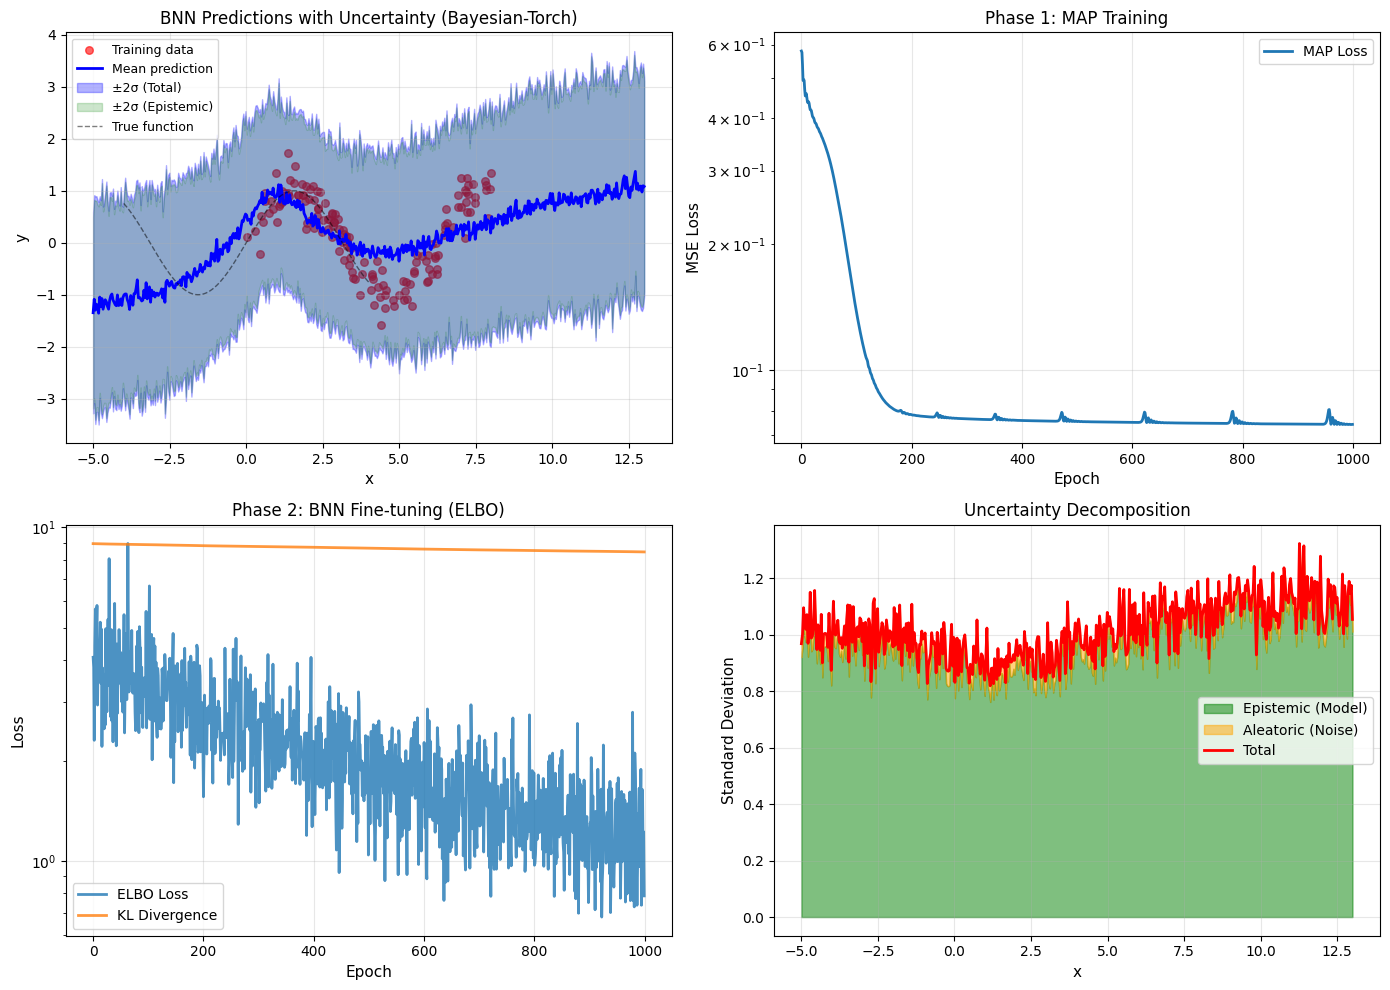

✓ Visualizations complete!


In [8]:
# Main regression plot with uncertainty
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predictions with uncertainty
ax = axes[0, 0]
ax.scatter(X_train_np, y_train_np, color='#ff7f0e', s=20, alpha=0.5, label='Training data')
ax.plot(x_test_np, f_mu, color='#1f77b4', linewidth=2, label='Mean prediction')
ax.fill_between(x_test_np,
                 f_mu - 2*pred_std,
                 f_mu + 2*pred_std,
                 alpha=0.35, color='#e67e22', label='±2σ (Total)')
ax.fill_between(x_test_np,
                 f_mu - 2*f_sigma,
                 f_mu + 2*f_sigma,
                 alpha=0.6, color='#8e44ad', label='±2σ (Epistemic)')

x_dense = np.linspace(-4, 4, 500)
y_true = np.sin(x_dense)
ax.plot(x_dense, y_true, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.7, label='True function')

ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('y', fontsize=11)
ax.set_title('BNN Predictions with Uncertainty (Bayesian-Torch)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: MAP training loss
ax = axes[0, 1]
ax.plot(map_losses, linewidth=2, label='MAP Loss')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MSE Loss', fontsize=11)
ax.set_title('Phase 1: MAP Training', fontsize=12)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 3: BNN ELBO and KL loss
ax = axes[1, 0]
ax.plot(bnn_losses, linewidth=2, label='ELBO Loss', alpha=0.8)
ax.plot(kl_losses, linewidth=2, label='KL Divergence', alpha=0.8)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Phase 2: BNN Fine-tuning (ELBO)', fontsize=12)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 4: Uncertainty decomposition
ax = axes[1, 1]
epistemic = f_sigma
aleatoric = np.full_like(f_sigma, f_sigma_aleatoric)
total = pred_std

ax.fill_between(x_test_np, 0, epistemic, alpha=0.5, label='Epistemic (Model)', color='green')
ax.fill_between(x_test_np, epistemic, total, alpha=0.5, label='Aleatoric (Noise)', color='orange')
ax.plot(x_test_np, total, 'r-', linewidth=2, label='Total')

ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('Standard Deviation', fontsize=11)
ax.set_title('Uncertainty Decomposition', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations complete!")




## 8. Summary & Key Metrics

In [9]:
print("\n" + "="*70)
print("BAYESIAN-TORCH BNN RESULTS SUMMARY")
print("="*70)

print("\n1. TRAINING METRICS:")
print(f"   Phase 1 (MAP) - Final MSE Loss:        {map_losses[-1]:.6f}")
print(f"   Phase 2 (BNN) - Final ELBO Loss:       {bnn_losses[-1]:.6f}")
print(f"   Phase 2 (BNN) - Final KL Divergence:   {kl_losses[-1]:.6f}")

print("\n2. PREDICTIVE UNCERTAINTY (on test set):")
print(f"   Epistemic std (model uncertainty):     {f_sigma.mean():.6f}")
print(f"   Aleatoric std (data noise):            {f_sigma_aleatoric:.6f}")
print(f"   Total predictive std:                  {pred_std.mean():.6f}")

print("\n3. BAYESIAN-TORCH SPECIFICS:")
print(f"   MC Samples for inference:              {num_mc_samples}")
print(f"   Layer type:                            Flipout (low-variance)")
print(f"   Initialization:                        MOPED (from MAP weights)")
print(f"   Prior structure:                       Gaussian (μ=0, σ=1)")

print("\n4. COMPARISON WITH LAPLACE APPROXIMATION:")
print("   Laplace-Torch (from previous notebook):")
print("   • Learned noise: σ ≈ 0.2819")
print("   • Epistemic std: ≈ 0.05")
print("   • Prior precision: 0.10079")
print("")
print("   Bayesian-Torch (this notebook):")
print(f"   • True noise: σ = {sigma_noise}")
print(f"   • Epistemic std: {f_sigma.mean():.6f} (from {num_mc_samples} MC samples)")
print(f"   • Learned via SVI during training")

print("\n5. KEY DIFFERENCES:")
print("   ┌─ Laplace: Post-hoc Gaussian approximation to fixed weights")
print("   └─ Bayesian-Torch: Direct SVI during training (variational posterior)")
print("")
print("   Laplace Strengths: Fast, requires trained model")
print("   Bayesian-Torch Strengths: Better scalability, learned distributions,")
print("                             low-variance Flipout estimator")

print("\n" + "="*70)





BAYESIAN-TORCH BNN RESULTS SUMMARY

1. TRAINING METRICS:
   Phase 1 (MAP) - Final MSE Loss:        0.074138
   Phase 2 (BNN) - Final ELBO Loss:       0.786689
   Phase 2 (BNN) - Final KL Divergence:   8.439800

2. PREDICTIVE UNCERTAINTY (on test set):
   Epistemic std (model uncertainty):     0.972421
   Aleatoric std (data noise):            0.300000
   Total predictive std:                  1.018092

3. BAYESIAN-TORCH SPECIFICS:
   MC Samples for inference:              100
   Layer type:                            Flipout (low-variance)
   Initialization:                        MOPED (from MAP weights)
   Prior structure:                       Gaussian (μ=0, σ=1)

4. COMPARISON WITH LAPLACE APPROXIMATION:
   Laplace-Torch (from previous notebook):
   • Learned noise: σ ≈ 0.2819
   • Epistemic std: ≈ 0.05
   • Prior precision: 0.10079

   Bayesian-Torch (this notebook):
   • True noise: σ = 0.3
   • Epistemic std: 0.972421 (from 100 MC samples)
   • Learned via SVI during training



## 9. Advanced Concepts & Extensions

### Flipout Estimator
- **Low-variance gradient estimator** for weight-space uncertainty
- Decorrelates gradients within a mini-batch
- **More efficient than standard reparameterization** for large networks

### MOPED Initialization
- Pre-train a deterministic (MAP) model first
- Use its weights to initialize the mean of the variational posterior
- Provides a strong starting point → faster convergence

### ELBO Optimization
- **Evidence Lower Bound**: $\text{ELBO} = \mathbb{E}_q[\log p(y|w)] - \text{KL}(q(w)||p(w))$
- Trades off likelihood (fit data well) vs regularization (stay close to prior)
- KL term scaled by batch size to prevent posterior collapse

### When to Use Each Method:
- **Laplace**: Small models, fast inference, require trained baseline
- **Bayesian-Torch**: Larger models, need learned uncertainty during training, ROCm-compatible